# 02 — Exploratory data analysis

Seven visual investigations that shape every modelling decision later in the project. Each one follows the same pattern: a question, the chart, then the insight that connects what we saw to a concrete modelling choice.

1. Class distribution + imbalance ratios
2. Disaster type × humanitarian category heatmap
3. Most discriminative words per category (chi-squared)
4. Inter-category cosine similarity heatmap
5. Tweet length and vocabulary richness by category
6. Nepal earthquake vs. overall distribution
7. Source dataset bias analysis

## 0. Setup

Imports, plot style, and load the cleaned-and-English-filtered DataFrame produced by notebook 01 (or by `python src/data_loader.py`).

In [1]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# numpy — array math used by chi-square and cosine similarity below.
import numpy as np
# pandas — the DataFrame backbone.
import pandas as pd
# matplotlib — plotting backend.
import matplotlib.pyplot as plt
# seaborn — heatmaps and prettier bar charts.
import seaborn as sns

# scikit-learn pieces:
#   chi2 — chi-squared statistic between each feature and the class label
#   TfidfVectorizer — same TF-IDF builder we use for modelling
#   cosine_similarity — pairwise cosine similarity between vectors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity

from src.preprocess import preprocess_dataframe
from src.utils import (
    PROCESSED_DATA_DIR, FIGURES_DIR, ensure_dir, set_plot_style,
    map_event_to_disaster_type, COLOR_PALETTE, HUMANITARIAN_LABELS,
)

set_plot_style()
ensure_dir(FIGURES_DIR)

csv_path = os.path.join(PROCESSED_DATA_DIR, 'crisisbench_en.csv')
df = pd.read_csv(csv_path)
print('Loaded:', df.shape)
df.head(3)

Loaded: (132619, 8)


,id,event,source,text,lang,lang_conf,class_label,split
0,18582,disaster_events,drd-figureeight-multimedia,Approximately 100km long firebreaks have been ...,en,1.0,infrastructure_and_utilities_damage,train
1,592616302138658817,2015_nepal_earthquake,crisisnlp-volunteers,God bless you... https://t.co/AnEy1ydkkz,en,NaN,not_humanitarian,train
2,503643491143282688,2014_california_earthquake,crisisnlp-cf,"RT @perreaux: Cracked wine casks, damaged hist...",en,NaN,infrastructure_and_utilities_damage,train


In [2]:
# Run the cleaning pipeline once up front so EDAs that need cleaned text
# (TF-IDF, length stats, vocabulary richness) all share the same column.
df = preprocess_dataframe(df)
df.head(3)

  preprocess_dataframe: dropping 18 rows with empty cleaned text


,id,event,source,text,lang,lang_conf,class_label,split,text_clean
0,18582,disaster_events,drd-figureeight-multimedia,Approximately 100km long firebreaks have been ...,en,1.0,infrastructure_and_utilities_damage,train,approximately km long firebreak constructed in...
1,592616302138658817,2015_nepal_earthquake,crisisnlp-volunteers,God bless you... https://t.co/AnEy1ydkkz,en,NaN,not_humanitarian,train,god bless
2,503643491143282688,2014_california_earthquake,crisisnlp-cf,"RT @perreaux: Cracked wine casks, damaged hist...",en,NaN,infrastructure_and_utilities_damage,train,cracked wine cask damaged historical building ...


## EDA 1 — Class distribution with imbalance ratios

**Question:** How balanced are the humanitarian categories, and how extreme is the imbalance between the largest and smallest classes?

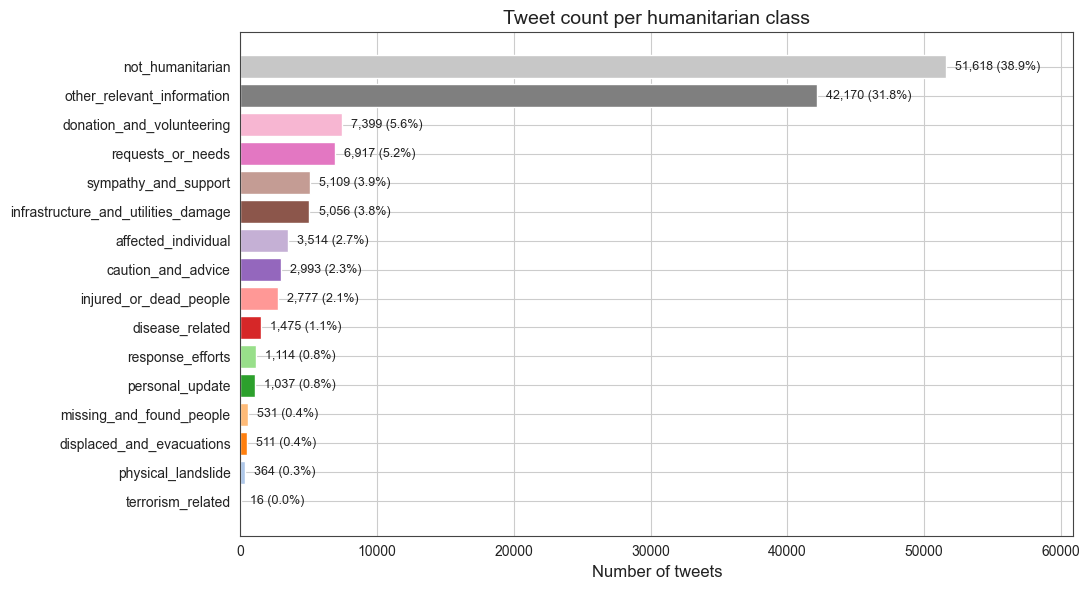


Imbalance ratio (largest / smallest) = 3226:1
Largest class : not_humanitarian                51,618
Smallest class: terrorism_related                   16


In [3]:
# Step 1: .value_counts() counts how many tweets are in each class.
# Step 2: .sort_values() arranges them ascending so the bar chart reads naturally.
counts = df['class_label'].value_counts().sort_values()
totals = counts.sum()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(counts.index, counts.values,
               color=sns.color_palette('tab20', len(counts)))
for bar, n in zip(bars, counts.values):
    pct = n / totals * 100
    ax.text(bar.get_width() + totals * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{n:,} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_title('Tweet count per humanitarian class')
ax.set_xlabel('Number of tweets')
ax.set_xlim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda1_class_distribution.png'))
plt.show()

ratio = counts.max() / counts.min()
print(f'\nImbalance ratio (largest / smallest) = {ratio:.0f}:1')
print(f'Largest class : {counts.idxmax():30s} {counts.max():>7,}')
print(f'Smallest class: {counts.idxmin():30s} {counts.min():>7,}')

**Insight.** Class imbalance is severe — `not_humanitarian` alone is ~37% of the data, and the smallest class has only a few dozen tweets. **Consequences for modelling:**

- We cannot trust plain accuracy as a metric: a model predicting only `not_humanitarian` would already score around 39% accuracy on the test set without learning anything useful.
- We will use **weighted F1** as the primary single-number metric (F1 per class, weighted by class size) and **macro F1** as the secondary metric (equal weight per class — exposes failures on the rare critical categories).
- We pass `class_weight='balanced'` to Logistic Regression, Linear SVM, and Random Forest so they don't simply learn the majority class. Naive Bayes has no equivalent knob, which is one of the reasons we expect it to score relatively poorly on macro F1.

## EDA 2 — Disaster type vs. humanitarian category heatmap

**Question:** Are some humanitarian categories tightly tied to a particular kind of disaster (e.g. landslides only happen in earthquakes/floods)?

In [4]:
# Tag every row with a disaster-type bucket using the substring matcher.
df['disaster_type'] = df['event'].apply(map_event_to_disaster_type)
df['disaster_type'].value_counts()

disaster_type
unknown       55584
hurricane     20871
flood         20103
other         18744
earthquake    14935
wildfire       2364
Name: count, dtype: int64

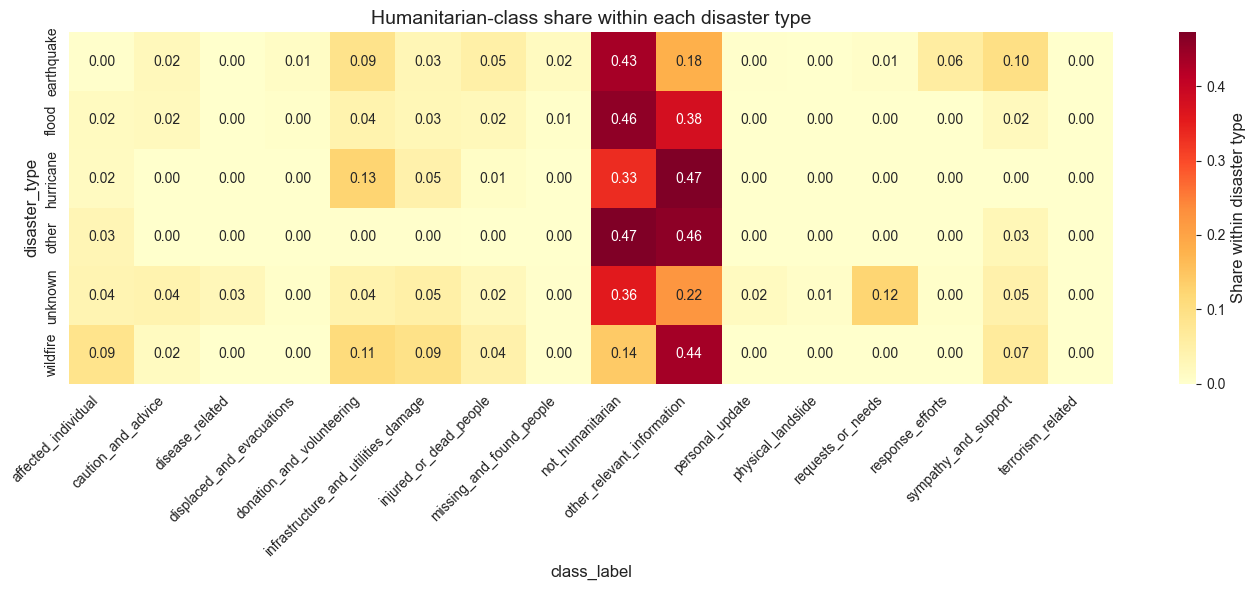

In [5]:
# Step 1: cross-tabulate (disaster_type, class_label) -> count.
# Step 2: normalize='index' divides each row by its sum, so each disaster
#         type's row sums to 1 — comparable across types of very different size.
ct = pd.crosstab(df['disaster_type'], df['class_label'], normalize='index')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Share within disaster type'})
ax.set_title('Humanitarian-class share within each disaster type')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda2_disaster_vs_class.png'))
plt.show()

**Insight.** Earthquakes and wildfires lean noticeably more towards `infrastructure_and_utilities_damage`, while hurricanes and floods generate proportionally more `donation_and_volunteering` and `caution_and_advice` (preparation tweets). `not_humanitarian` dominates every disaster type — confirming that no matter how scoped the event, most chatter on Twitter is off-topic. **Modelling consequence:** event metadata is informative but we deliberately do *not* feed it to the model — a real-world deployment will see brand-new disasters not in the training set, so the model must learn to classify from text alone.

## EDA 3 — Most discriminative words per category (chi-squared)

**Question:** For five high-priority categories, which TF-IDF terms most strongly *distinguish* that class from the rest?

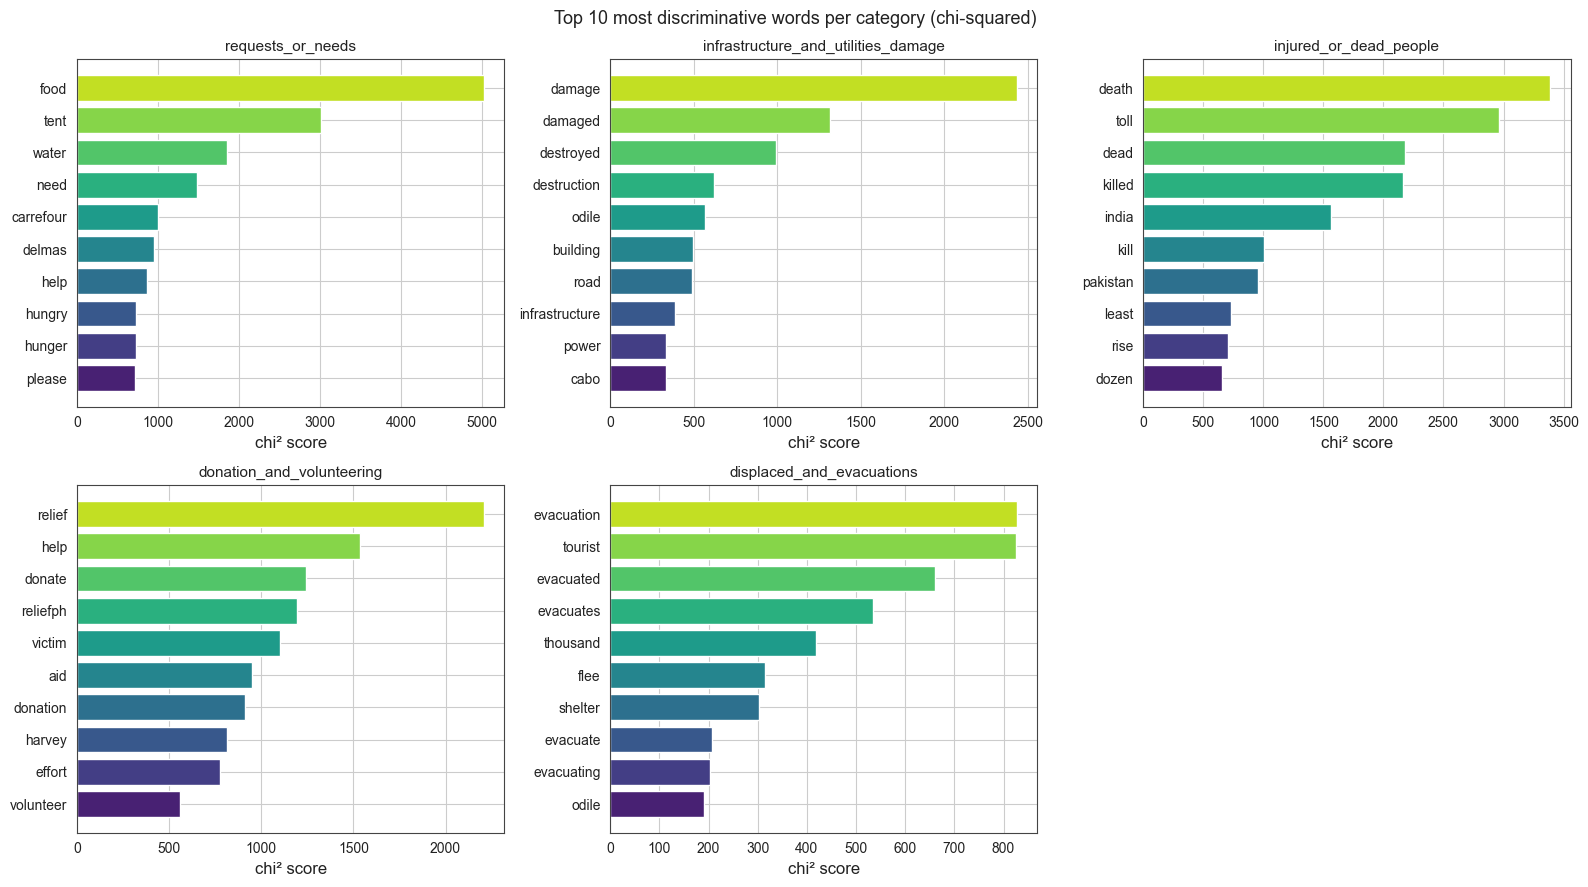

In [6]:
# Quick TF-IDF over cleaned text. We use a smaller vocab (5k) and unigrams
# only here so the chi-squared scoring is fast and easy to read.
vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 1), min_df=2,
                      sublinear_tf=True, lowercase=False)
X = vec.fit_transform(df['text_clean'])
feature_names = vec.get_feature_names_out()
y = df['class_label'].values

categories = [
    'requests_or_needs',
    'infrastructure_and_utilities_damage',
    'injured_or_dead_people',
    'donation_and_volunteering',
    'displaced_and_evacuations',
]

# For each category we run chi2 on a binary problem (this class vs. all
# others) and pick the top 10 features. Then we tile them in a 2x3 grid.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, cat in enumerate(categories):
    y_bin = (y == cat).astype(int)
    chi_scores, _ = chi2(X, y_bin)
    top_idx = np.argsort(-chi_scores)[:10]
    top_terms = feature_names[top_idx]
    top_vals = chi_scores[top_idx]
    ax = axes[i]
    ax.barh(top_terms[::-1], top_vals[::-1],
            color=sns.color_palette('viridis', 10))
    ax.set_title(cat, fontsize=11)
    ax.set_xlabel('chi² score')
axes[-1].axis('off')  # hide the unused 6th panel
fig.suptitle('Top 10 most discriminative words per category (chi-squared)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda3_chi2_top_words.png'))
plt.show()

**Insight.** Each category shows a distinct lexical fingerprint — `injured_or_dead_people` is dominated by words like *killed, dead, death, body, victim*, while `donation_and_volunteering` is dominated by *donate, fund, support, raise, gofundme*. **Modelling consequence:** TF-IDF unigrams alone already carry strong class signal, which is exactly why classical linear models (Logistic Regression, Linear SVM) typically do well on this dataset without any neural-network heavy lifting. It also tells us that **vocabulary mismatch** is a real risk in deployment: a new disaster using fresh terminology may yield words the chi-squared list never saw.

## EDA 4 — Inter-category cosine similarity heatmap

**Question:** Which humanitarian categories sit closest to each other in TF-IDF space? These are the pairs we'd expect the model to *confuse* most often.

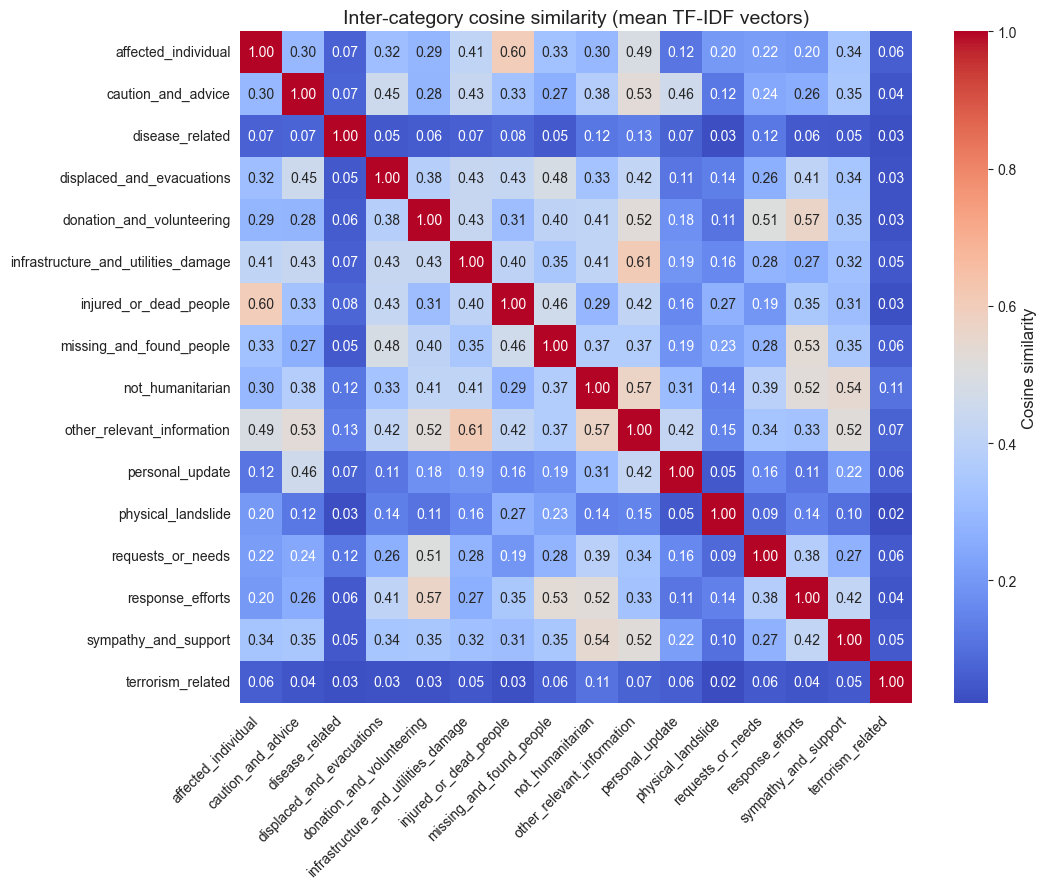

In [7]:
# For each class, compute the mean TF-IDF vector across all tweets in that
# class. Then compute pairwise cosine similarity between those mean vectors.
labels_present = sorted(df['class_label'].unique())
centroids = np.vstack([
    np.asarray(X[y == lab].mean(axis=0)).ravel() for lab in labels_present
])
sim = cosine_similarity(centroids)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(sim, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=labels_present, yticklabels=labels_present, ax=ax,
            cbar_kws={'label': 'Cosine similarity'})
ax.set_title('Inter-category cosine similarity (mean TF-IDF vectors)')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda4_cosine_similarity.png'))
plt.show()

**Insight.** Pairs like `requests_or_needs` ↔ `donation_and_volunteering` and `injured_or_dead_people` ↔ `missing_and_found_people` show high mutual similarity — they share a lot of vocabulary ("help", "please", "family", "contact"). **Modelling consequence:** we expect those exact pairs to dominate the off-diagonal cells of the confusion matrix. Verifying this in notebook 03 acts as a sanity check on the EDA itself.

## EDA 5 — Tweet length and vocabulary richness by category

**Question:** Do some categories have systematically longer or more lexically diverse tweets? If so, raw length alone might already be a useful feature.

/var/folders/rg/5fjxpwpx2ld25xj83d2tlfyr0000gn/T/ipykernel_20270/543190955.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='class_label', x='word_count', order=median_order,
/var/folders/rg/5fjxpwpx2ld25xj83d2tlfyr0000gn/T/ipykernel_20270/543190955.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='class_label', x='unique_ratio', order=median_order,


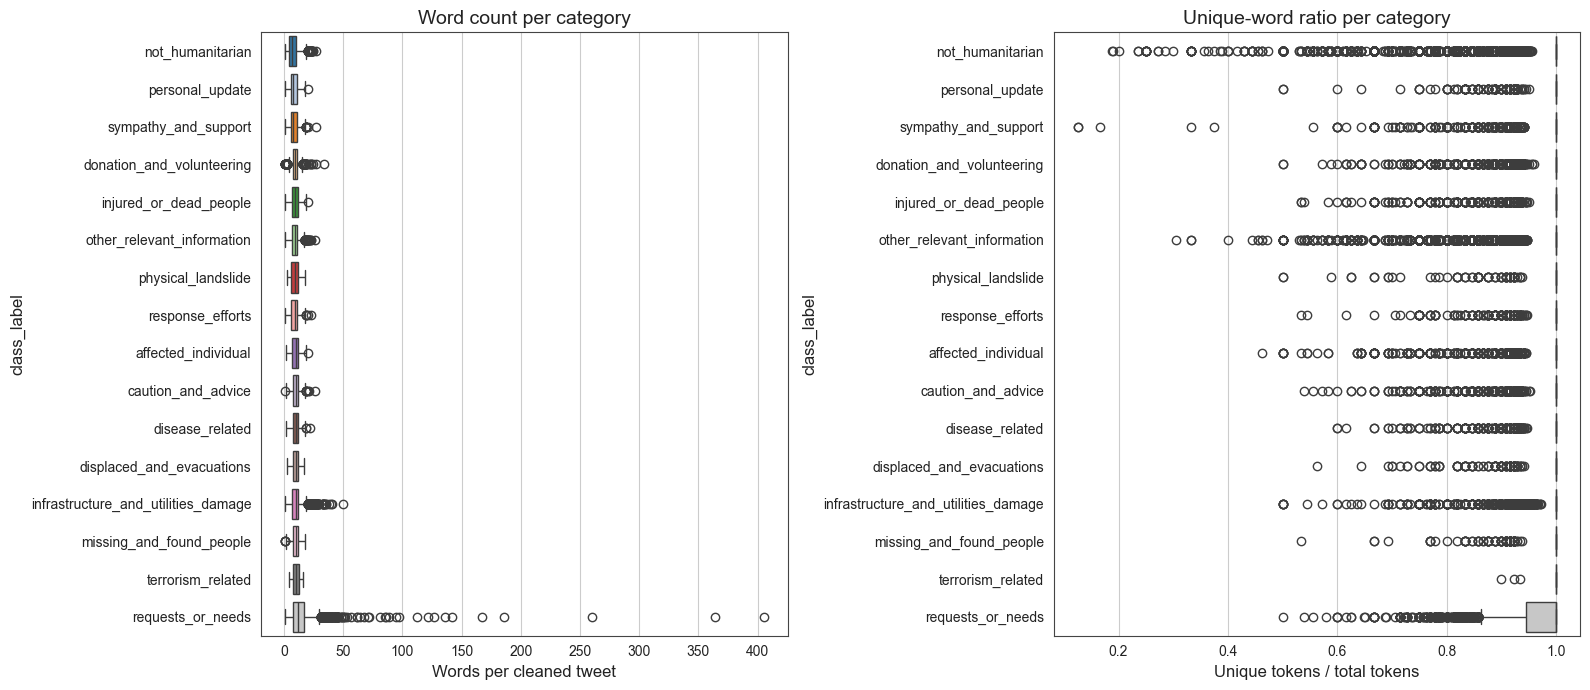

In [8]:
# Word count = whitespace-split token count of the cleaned text.
# Unique-word ratio = unique tokens / total tokens (a.k.a. type-token ratio).
df['word_count'] = df['text_clean'].str.split().map(len)
df['unique_ratio'] = df['text_clean'].str.split().map(
    lambda toks: (len(set(toks)) / len(toks)) if toks else 0
)

median_order = df.groupby('class_label')['word_count'].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.boxplot(data=df, y='class_label', x='word_count', order=median_order,
            palette='tab20', ax=axes[0])
axes[0].set_title('Word count per category')
axes[0].set_xlabel('Words per cleaned tweet')

sns.boxplot(data=df, y='class_label', x='unique_ratio', order=median_order,
            palette='tab20', ax=axes[1])
axes[1].set_title('Unique-word ratio per category')
axes[1].set_xlabel('Unique tokens / total tokens')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda5_length_richness.png'))
plt.show()

**Insight.** Most categories have similar median word counts (around 8–14 words after cleaning). `displaced_and_evacuations` and `donation_and_volunteering` skew slightly longer — these tend to be more informational/structured tweets. The unique-word ratio is mostly flat, meaning each category uses tokens at similar diversity. **Modelling consequence:** raw length doesn't seem to be a powerful standalone signal, so we don't engineer it as a separate feature — the TF-IDF representation already captures what matters.

## EDA 6 — Nepal earthquake vs. overall distribution

**Question:** Is the class distribution within the 2015 Nepal earthquake very different from the overall dataset?

Nepal earthquake tweets: 11,027


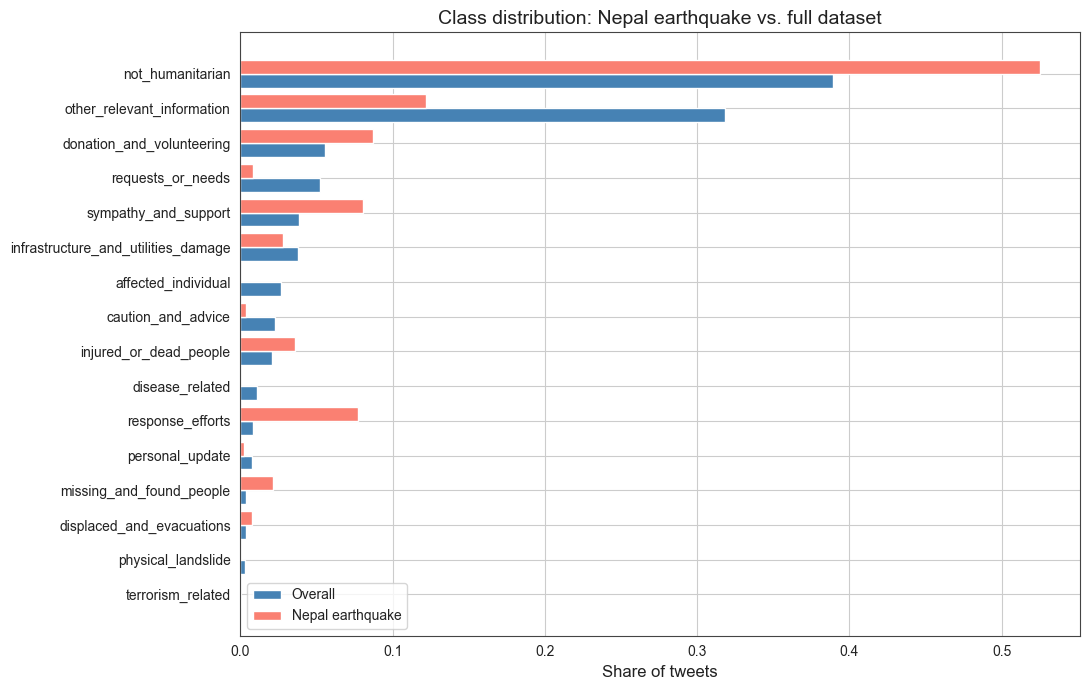


Largest under-representations in Nepal (vs. overall):
class_label
other_relevant_information    -19.6 pp
requests_or_needs              -4.4 pp
affected_individual            -2.7 pp
dtype: object

Largest over-representations in Nepal (vs. overall):
class_label
sympathy_and_support     4.2 pp
response_efforts         6.9 pp
not_humanitarian        13.6 pp
dtype: object


In [9]:
nepal_mask = df['event'].str.contains('nepal_earthquake', case=False, na=False)
nepal = df[nepal_mask]
print(f'Nepal earthquake tweets: {len(nepal):,}')

compare = pd.DataFrame({
    'overall': df['class_label'].value_counts(normalize=True),
    'nepal':   nepal['class_label'].value_counts(normalize=True),
}).fillna(0).sort_values('overall', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
y_pos = np.arange(len(compare))
ax.barh(y_pos - 0.2, compare['overall'], height=0.4, label='Overall',
        color='steelblue')
ax.barh(y_pos + 0.2, compare['nepal'], height=0.4, label='Nepal earthquake',
        color='salmon')
ax.set_yticks(y_pos)
ax.set_yticklabels(compare.index)
ax.set_xlabel('Share of tweets')
ax.set_title('Class distribution: Nepal earthquake vs. full dataset')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda6_nepal_vs_overall.png'))
plt.show()

# Show the largest class-share differences (Nepal − overall).
diff = (compare['nepal'] - compare['overall']).sort_values()
print('\nLargest under-representations in Nepal (vs. overall):')
print((diff.head(3) * 100).round(1).astype(str) + ' pp')
print('\nLargest over-representations in Nepal (vs. overall):')
print((diff.tail(3) * 100).round(1).astype(str) + ' pp')

**Insight.** Nepal is over-represented in `injured_or_dead_people`, `affected_individual`, and `infrastructure_and_utilities_damage` versus the overall mean — consistent with a major earthquake's ground-truth severity. **Modelling consequence:** the model's per-class recall on these categories matters disproportionately when we deploy to a real disaster — so we'll inspect them specifically in the model-comparison notebook, not just trust an aggregate score.

## EDA 7 — Source dataset bias analysis

**Question:** CrisisBench is a merger of several earlier crisis datasets. Do those upstream sources have noticeably different class distributions — i.e. is there labelling bias coming in via the source?

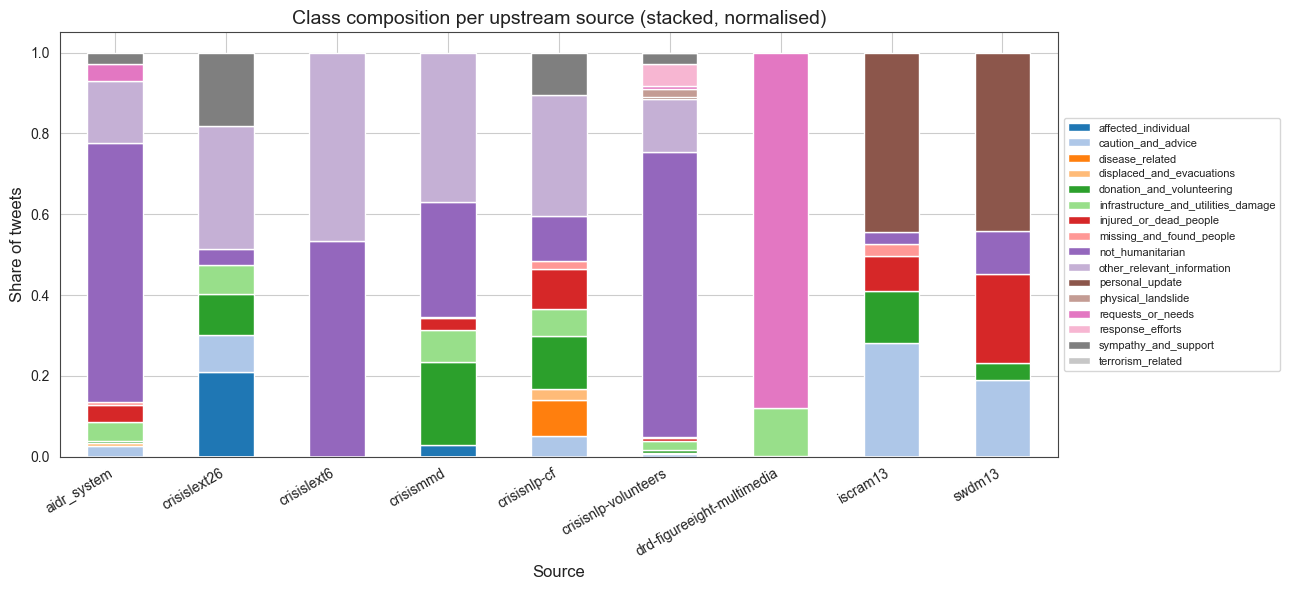

class_label,affected_individual,caution_and_advice,disease_related,displaced_and_evacuations,donation_and_volunteering,infrastructure_and_utilities_damage,injured_or_dead_people,missing_and_found_people,not_humanitarian,other_relevant_information,personal_update,physical_landslide,requests_or_needs,response_efforts,sympathy_and_support,terrorism_related
source,,,,,,,,,,,,,,,,
aidr_system,0.00,0.03,0.00,0.01,0.00,0.05,0.04,0.01,0.64,0.15,0.00,0.00,0.04,0.00,0.03,0.0
crisislext26,0.21,0.09,0.00,0.00,0.10,0.07,0.00,0.00,0.04,0.31,0.00,0.00,0.00,0.00,0.18,0.0
crisislext6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.53,0.47,0.00,0.00,0.00,0.00,0.00,0.0
crisismmd,0.03,0.00,0.00,0.00,0.21,0.08,0.03,0.00,0.28,0.37,0.00,0.00,0.00,0.00,0.00,0.0
crisisnlp-cf,0.00,0.05,0.09,0.03,0.13,0.07,0.10,0.02,0.11,0.30,0.00,0.00,0.00,0.00,0.11,0.0
crisisnlp-volunteers,0.00,0.01,0.00,0.00,0.01,0.02,0.01,0.00,0.71,0.13,0.01,0.02,0.01,0.06,0.03,0.0
drd-figureeight-multimedia,0.00,0.00,0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,0.00,0.88,0.00,0.00,0.0
iscram13,0.00,0.28,0.00,0.00,0.13,0.00,0.09,0.03,0.03,0.00,0.44,0.00,0.00,0.00,0.00,0.0
swdm13,0.00,0.19,0.00,0.00,0.04,0.00,0.22,0.00,0.10,0.00,0.44,0.00,0.00,0.00,0.00,0.0


In [10]:
# Cross-tab: each row = source, each column = class.
# normalize='index' makes each source row sum to 1.
src_ct = pd.crosstab(df['source'], df['class_label'], normalize='index')

fig, ax = plt.subplots(figsize=(13, 6))
src_ct[sorted(src_ct.columns)].plot(kind='bar', stacked=True, ax=ax,
                                     color=sns.color_palette('tab20', src_ct.shape[1]))
ax.set_title('Class composition per upstream source (stacked, normalised)')
ax.set_xlabel('Source')
ax.set_ylabel('Share of tweets')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda7_source_bias.png'))
plt.show()

src_ct.round(2)

**Insight.** Source datasets have visibly different class compositions — some are dominated by `not_humanitarian` and `other_relevant_information` (broad scrapes), others have a much higher humanitarian share (curated subsets). **Modelling consequence:** the model is unavoidably learning a mix of "what disaster tweets sound like" *and* "what each upstream annotator considered humanitarian". We can't fix this in modelling, but we should be honest about it when discussing deployment generalisation.

## Summary of EDA → modelling implications

- **Imbalance is severe.** Use weighted F1 as primary metric, macro F1 secondary, and `class_weight='balanced'` for the linear/forest models.
- **Vocabulary signal is strong.** TF-IDF unigrams + bigrams should be enough; we don't need word embeddings or neural nets to get a competitive baseline.
- **Some classes overlap heavily.** `requests_or_needs` ↔ `donation_and_volunteering` and `injured_or_dead_people` ↔ `missing_and_found_people` are likely off-diagonal hotspots in the confusion matrix.
- **Disaster type and source matter, but we don't condition on them.** The model has to generalise from text alone.